# M09 — Detection-Guided Candidate Lesion Regions

**EEEM068 Applied Machine Learning — MaxViT-Tiny Fine-Grained Detection Ablation**

**Research question:** Does adding deterministic candidate red-lesion regions to the M07
MaxViT input improve recognition of subtle DR abnormalities, particularly Mild DR, while
preserving ordinal agreement?

**Hypothesis:** Candidate red-lesion regions may direct the classifier toward small dark
abnormalities that are easily lost when the full retinal image is resized to 224×224. This
may reduce Mild-to-No-DR errors, although inaccurate candidate regions may introduce
false-positive attention and reduce specificity.

The regions used here are produced by a fixed, deterministic classical image-processing
pipeline applied to the image alone — they are **pseudo-detection regions** /
**candidate lesion regions**, not ground-truth bounding boxes, expert lesion annotations, or
medically confirmed lesions.

M09 is copied from **M07** (`M07_ordinal_aware_loss.ipynb`), not M08. Every M07 control
listed in the table below is retained unchanged; the only intended experimental change is a
fourth input channel carrying the coarse candidate-region guidance map, and the minimal
adaptation of MaxViT's input stem required to accept it. The internal test set is not loaded
anywhere in this notebook.

| Setting | M09 value |
|---|---|
| Model | `maxvit_tiny_tf_224.in1k` |
| Seed | 42 |
| RGB image size | 224 × 224 |
| Classes | 5 |
| Batch size | 32 |
| Learning rate | 5e-5 |
| Weight decay | 0.05 |
| Maximum epochs | 25 |
| Warm-up epochs | 3 |
| Early-stopping patience | 7 |
| Gradient clipping | 1.0 |
| Label smoothing | 0.0 |
| Class weights | Balanced, clipped to [0.5, 2.5] |
| Weighted sampler | No |
| Training sampler | Ordinary shuffle |
| Loss | M07 ordinal-aware weighted CE |
| Ordinal penalty weight | 0.5 |
| Optimiser | AdamW |
| Scheduler | Linear warm-up then cosine annealing |
| Training mode | Single-stage full fine-tuning |
| Primary checkpoint metric | Validation QWK |
| Tie-break | Validation macro-F1 |
| Preprocessing | P0 |
| Internal test | Must not be loaded |

## 2. Imports

In [1]:
import json
import random
from pathlib import Path

import cv2
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

from torchvision import transforms
import torchvision.transforms.functional as TF

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.utils.class_weight import compute_class_weight

print("Imports OK.")

Imports OK.


## 3. Experiment configuration

Runs before reproducibility/paths, since `SEED` is defined here and later cells depend on it.
`RUN_NAME`/`EXPERIMENT_ID` are defined only here, not repeated elsewhere.

Every M07 control is copied verbatim (see the table in Section 1). The detection-pipeline
parameters are new to M09 and are fixed *before* any validation result is examined — they are
not tuned against validation performance.

In [2]:
EXPERIMENT_ID = "M09"
RUN_NAME = "M09_detection_guided_regions"
EXPERIMENT_TYPE = "fine_grained_detection_ablation"
PREDECESSOR_EXPERIMENT = "M07_ordinal_aware_loss"

MODEL_NAME = "maxvit_tiny_tf_224.in1k"
IMAGE_SIZE = 224
NUM_CLASSES = 5
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]
SEED = 42

VIT_MEAN = (0.485, 0.456, 0.406)
VIT_STD = (0.229, 0.224, 0.225)

BATCH_SIZE = 32
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.05

MAX_EPOCHS = 25
WARMUP_EPOCHS = 3
EARLY_STOPPING_PATIENCE = 7

LABEL_SMOOTHING = 0.0
GRAD_CLIP = 1.0
QWK_TOLERANCE = 1e-4
NUM_WORKERS = 4

TRAINING_MODE = "single_stage"

USE_CLASS_WEIGHTS = True
USE_WRS = False
CLASS_WEIGHT_METHOD = "balanced"
CLASS_WEIGHT_CLIP_MIN = 0.5
CLASS_WEIGHT_CLIP_MAX = 2.5

ORDINAL_PENALTY_WEIGHT = 0.5

# Exact M07 safe-retinal augmentation.
HORIZONTAL_FLIP_PROBABILITY = 0.5
ROTATION_DEGREES = 7
BRIGHTNESS_JITTER = 0.05
CONTRAST_JITTER = 0.05
SATURATION_JITTER = 0.02
HUE_JITTER = 0.0
TRANSLATE_FRACTION = 0.02
SCALE_MIN = 0.98
SCALE_MAX = 1.02

# --- New in M09: deterministic pseudo-detection parameters (fixed before any
# validation result is examined). ---
DETECTION_SIZE = 512
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)
BACKGROUND_SIGMA = 12.0
DARK_RESPONSE_PERCENTILE = 97.0

MIN_COMPONENT_AREA = 3
MAX_COMPONENT_AREA = 350
MAX_ASPECT_RATIO = 4.0

MAX_CANDIDATE_BOXES = 12
BOX_PADDING = 4
GUIDANCE_MAP_TYPE = "binary_bounding_regions"

INPUT_CHANNELS = 4
RGB_CHANNELS = 3
GUIDANCE_CHANNELS = 1

print(f"Experiment : {EXPERIMENT_ID} / {RUN_NAME}")
print(f"Predecessor: {PREDECESSOR_EXPERIMENT}")
print(f"LR={LEARNING_RATE}  WD={WEIGHT_DECAY}  BATCH={BATCH_SIZE}  "
      f"MAX_EPOCHS={MAX_EPOCHS}  PATIENCE={EARLY_STOPPING_PATIENCE}")
print(f"Input channels: {INPUT_CHANNELS} (RGB={RGB_CHANNELS} + guidance={GUIDANCE_CHANNELS})")

Experiment : M09 / M09_detection_guided_regions
Predecessor: M07_ordinal_aware_loss
LR=5e-05  WD=0.05  BATCH=32  MAX_EPOCHS=25  PATIENCE=7
Input channels: 4 (RGB=3 + guidance=1)


## 4. Reproducibility and device

In [3]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

if device.type != "cuda":
    raise RuntimeError(
        "CUDA GPU is not available. Do not start this training run on CPU."
    )

Device: cuda
GPU: NVIDIA RTX A4000


## 5. Paths and output directories

`M07_LOG_DIR` points at M07's own log folder, used later for the config-audit (Section 16)
and the M07-vs-M09 comparison (Section 21) — read-only, M07's checkpoint is never loaded.

In [4]:
PROJECT_ROOT = Path(
    "/scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy"
)

SPLITS_DIR = PROJECT_ROOT / "configs" / "splits"

TRAIN_CSV = SPLITS_DIR / "train_split.csv"
VAL_CSV = SPLITS_DIR / "val_split.csv"
# The internal test split is intentionally not loaded anywhere in this
# notebook. It stays locked until a final MaxViT configuration is selected
# across the full M01-M09+ series.

RUN_LOG_DIR = PROJECT_ROOT / "logs" / "maxvit_tiny" / RUN_NAME
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "maxvit_tiny" / RUN_NAME
FIGURE_DIR = PROJECT_ROOT / "results" / "figures" / "maxvit_tiny" / RUN_NAME

for directory in [RUN_LOG_DIR, CHECKPOINT_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "best.pt"

M07_LOG_DIR = PROJECT_ROOT / "logs" / "maxvit_tiny" / PREDECESSOR_EXPERIMENT

# Local, git-ignored cache of deterministic guidance maps (Section 11). Recomputing the
# detector on every epoch for ~24,586 training images x up to 25 epochs would mean 600,000+
# detector calls; caching once and reloading avoids that CPU bottleneck. Add this path (or
# "cache/" generally) to .gitignore - the cache is derived data, not something to commit.
CACHE_DIR = PROJECT_ROOT / "cache" / "maxvit_tiny" / "M09_guidance_maps"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run          : maxvit_tiny/{RUN_NAME}")
print(f"Logs         -> {RUN_LOG_DIR}")
print(f"Checkpoints  -> {CHECKPOINT_DIR}")
print(f"Figures      -> {FIGURE_DIR}")
print(f"M07 logs     -> {M07_LOG_DIR}  (read-only; checkpoint never loaded)")
print(f"Guidance cache -> {CACHE_DIR}  (git-ignored; not committed)")

Run          : maxvit_tiny/M09_detection_guided_regions
Logs         -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M09_detection_guided_regions
Checkpoints  -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/checkpoints/maxvit_tiny/M09_detection_guided_regions
Figures      -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M09_detection_guided_regions
M07 logs     -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M07_ordinal_aware_loss  (read-only; checkpoint never loaded)
Guidance cache -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/cache/maxvit_tiny/M09_guidance_maps  (git-ignored; not committed)


## 6. Load patient-grouped CSV files and verify zero patient overlap

Same `train_split.csv` / `val_split.csv` used throughout M01-M08.

In [5]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

required_columns = {"image", "level", "patient_id", "eye", "filepath"}

for split_name, frame in [("train", train_df), ("validation", val_df)]:
    missing_columns = required_columns - set(frame.columns)
    if missing_columns:
        raise ValueError(f"{split_name} is missing columns: {sorted(missing_columns)}")

    missing_files = frame.loc[~frame["filepath"].map(lambda path: Path(path).exists())]
    if len(missing_files) > 0:
        raise FileNotFoundError(
            f"{split_name} contains {len(missing_files):,} missing image files."
        )

train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])
assert train_patients.isdisjoint(val_patients), "Patient overlap detected."

print(f"Train      : {len(train_df):,}  ({len(train_patients):,} patients)")
print(f"Validation : {len(val_df):,}  ({len(val_patients):,} patients)")
print("Patient overlap check: PASSED (zero overlap)")

Train      : 24,586  (12,293 patients)
Validation : 5,270  (2,635 patients)
Patient overlap check: PASSED (zero overlap)


## 7. P0 preprocessing

Identical crop/pad pipeline used throughout the project. `_common_preprocessing_full` returns
the cropped-and-padded (but not yet resized) square image — needed here because the detection
pipeline (Section 8) works on its own 512×512 resize of this same crop, independent of the
224×224 resize used for the RGB channels.

In [6]:
def _load_rgb(path: str) -> np.ndarray:
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        raise ValueError(f"Cannot decode image: {path}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def _crop_black_borders(img: np.ndarray, threshold: int = 10) -> np.ndarray:
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    margin = int(min(w, h) * 0.02)
    x, y = max(0, x - margin), max(0, y - margin)
    w = min(img.shape[1] - x, w + 2 * margin)
    h = min(img.shape[0] - y, h + 2 * margin)
    return img[y:y + h, x:x + w]


def _pad_square(img: np.ndarray) -> np.ndarray:
    h, w = img.shape[:2]
    side = max(h, w)
    canvas = np.zeros((side, side, 3), dtype=img.dtype)
    y = (side - h) // 2
    x = (side - w) // 2
    canvas[y:y + h, x:x + w] = img
    return canvas


def preprocess_p0_full(image_path: str) -> np.ndarray:
    """Load, crop black borders, pad to square. No resize yet (unlike preprocess_p0
    elsewhere in the project) — the caller decides the target resolution, since this
    notebook needs both a 224x224 RGB resize and an independent 512x512 detection resize
    from the same underlying crop."""
    img = _load_rgb(image_path)
    img = _crop_black_borders(img)
    img = _pad_square(img)
    return img


print("P0 preprocessing ready (crop + pad; resize handled per-use downstream).")

P0 preprocessing ready (crop + pad; resize handled per-use downstream).


## 8. Deterministic pseudo-detection of candidate lesion regions

A fixed, deterministic classical image-processing pipeline — no learned detector, no labels.
`generate_candidate_regions()` only ever receives an image, never a DR grade.

Pipeline: resize the P0 crop to 512×512 → take the green channel (red lesions typically show
strongest contrast there) → CLAHE-enhance → estimate a slowly-varying background via a wide
Gaussian blur → the "dark response" is how much darker each pixel is than its local background
→ threshold at a fixed percentile → light morphological opening to remove speckle noise →
connected components → reject components that are too small, too large, or too elongated to be
plausible microaneurysm/haemorrhage candidates → rank the rest by response strength → keep at
most `MAX_CANDIDATE_BOXES` → pad each into a bounding rectangle → fill the rectangles onto a
512×512 map → resize to 224×224 with **nearest-neighbour** interpolation (this is a binary
region map, not a smooth image — bilinear interpolation would blur the box edges into
meaningless intermediate values).

Note this deliberately produces **coarse rectangular regions**, not exact lesion-shaped pixel
masks — that finer-grained pseudo-segmentation is out of scope for M09 and is reserved for a
possible M10.

The threshold step also guards an edge case: if the retinal field's dark-response percentile
comes out at or below zero, thresholding with a plain `>=` comparison would let black padding
pixels (which are exactly 0) pass the test too. The threshold check requires `dark_response >
0` in addition to `>= threshold_value`, and returns an empty guidance map outright when the
field has no genuinely dark response at all, so black padding is never mistaken for a
candidate region.

In [7]:
def generate_candidate_regions(image_rgb_full: np.ndarray):
    """Deterministic pseudo-detection of candidate dark/red lesion regions.

    Parameters
    ----------
    image_rgb_full : the P0-cropped-and-padded (but not yet resized) RGB image.

    Returns
    -------
    guidance_map : (IMAGE_SIZE, IMAGE_SIZE) float32 array in [0, 1].
    boxes        : list of (x0, y0, x1, y1) accepted bounding boxes, in 512x512
                   detection-resolution coordinates (for visualisation only).
    """
    detection_image = cv2.resize(
        image_rgb_full, (DETECTION_SIZE, DETECTION_SIZE), interpolation=cv2.INTER_AREA
    )

    green = detection_image[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID_SIZE)
    enhanced_green = clahe.apply(green)

    background = cv2.GaussianBlur(enhanced_green, (0, 0), BACKGROUND_SIGMA)
    dark_response = cv2.subtract(background, enhanced_green)

    gray = cv2.cvtColor(detection_image, cv2.COLOR_RGB2GRAY)
    field_mask = (gray > 10).astype(np.uint8)
    dark_response = dark_response * field_mask

    field_pixels = dark_response[field_mask > 0]

    if field_pixels.size == 0 or field_pixels.max() <= 0:
        threshold_value = 255.0
        binary = np.zeros_like(field_mask, dtype=np.uint8)
    else:
        threshold_value = float(
            np.percentile(field_pixels, DARK_RESPONSE_PERCENTILE)
        )

        binary = (
            (dark_response >= threshold_value)
            & (dark_response > 0)
            & (field_mask > 0)
        ).astype(np.uint8) * 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

    candidates = []
    for label_id in range(1, num_labels):
        area = stats[label_id, cv2.CC_STAT_AREA]
        w = stats[label_id, cv2.CC_STAT_WIDTH]
        h = stats[label_id, cv2.CC_STAT_HEIGHT]

        if area < MIN_COMPONENT_AREA or area > MAX_COMPONENT_AREA:
            continue

        aspect_ratio = max(w, h) / max(1, min(w, h))
        if aspect_ratio > MAX_ASPECT_RATIO:
            continue

        response_strength = float(dark_response[labels == label_id].mean())
        x = stats[label_id, cv2.CC_STAT_LEFT]
        y = stats[label_id, cv2.CC_STAT_TOP]
        candidates.append((response_strength, x, y, w, h))

    candidates.sort(key=lambda c: c[0], reverse=True)
    candidates = candidates[:MAX_CANDIDATE_BOXES]

    guidance_map_full = np.zeros((DETECTION_SIZE, DETECTION_SIZE), dtype=np.uint8)
    boxes = []
    for _, x, y, w, h in candidates:
        x0 = max(0, x - BOX_PADDING)
        y0 = max(0, y - BOX_PADDING)
        x1 = min(DETECTION_SIZE, x + w + BOX_PADDING)
        y1 = min(DETECTION_SIZE, y + h + BOX_PADDING)
        guidance_map_full[y0:y1, x0:x1] = 1
        boxes.append((int(x0), int(y0), int(x1), int(y1)))

    guidance_map = cv2.resize(
        guidance_map_full, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST
    ).astype(np.float32)

    return guidance_map, boxes


print("Deterministic candidate-region detector ready.")
print(f"MAX_CANDIDATE_BOXES={MAX_CANDIDATE_BOXES}  DARK_RESPONSE_PERCENTILE={DARK_RESPONSE_PERCENTILE}")

Deterministic candidate-region detector ready.
MAX_CANDIDATE_BOXES=12  DARK_RESPONSE_PERCENTILE=97.0


## 9. Detection sanity checks

Run before training on a fixed random sample of training images: confirm the guidance map is
well-formed (finite, correct shape, values in [0, 1]), check how many candidate boxes are
typically found, what fraction of images get zero boxes at all (not automatically a failure —
some images genuinely may show nothing above threshold), and confirm the detector is not
degenerately marking the entire retina as one giant region.

In [8]:
detection_sample_df = train_df.sample(
    n=min(200, len(train_df)), random_state=SEED
).reset_index(drop=True)

box_counts = []
coverages = []
zero_box_count = 0

for _, row in tqdm(detection_sample_df.iterrows(), total=len(detection_sample_df), desc="detection sanity check"):
    image_full = preprocess_p0_full(row["filepath"])
    guidance_map, boxes = generate_candidate_regions(image_full)

    assert guidance_map.ndim == 2
    assert guidance_map.shape == (IMAGE_SIZE, IMAGE_SIZE)
    assert np.isfinite(guidance_map).all()
    assert guidance_map.min() >= 0
    assert guidance_map.max() <= 1

    coverage = float(guidance_map.mean())
    assert 0.0 <= coverage <= 1.0

    box_counts.append(len(boxes))
    coverages.append(coverage)
    if len(boxes) == 0:
        zero_box_count += 1

box_counts = np.array(box_counts)
coverages = np.array(coverages)

print(f"Sampled images                 : {len(detection_sample_df)}")
print(f"Mean candidate boxes per image : {box_counts.mean():.2f}")
print(f"Median candidate boxes         : {np.median(box_counts):.0f}")
print(f"Max candidate boxes            : {box_counts.max()}")
print(f"Images with zero candidates    : {zero_box_count} ({zero_box_count / len(detection_sample_df):.1%})")
print(f"Mean guidance coverage         : {coverages.mean():.4f}")
print(f"Max guidance coverage          : {coverages.max():.4f}")

assert coverages.max() < 0.5, (
    "Detector appears to be marking a large fraction of the retina as candidate region "
    "on at least one sampled image - check DARK_RESPONSE_PERCENTILE / MAX_COMPONENT_AREA."
)

print("Detection sanity checks: PASSED")

detection sanity check:   0%|          | 0/200 [00:00<?, ?it/s]

Sampled images                 : 200
Mean candidate boxes per image : 11.99
Median candidate boxes         : 12
Max candidate boxes            : 12
Images with zero candidates    : 0 (0.0%)
Mean guidance coverage         : 0.0250
Max guidance coverage          : 0.0549
Detection sanity checks: PASSED


## 10. Visual evidence before training

At least two examples per DR grade, showing the P0 retinal image, the detected candidate
boxes overlaid, and the final coarse guidance channel. **These boxes are generated by
deterministic image processing on the image alone — they are not expert annotations.**

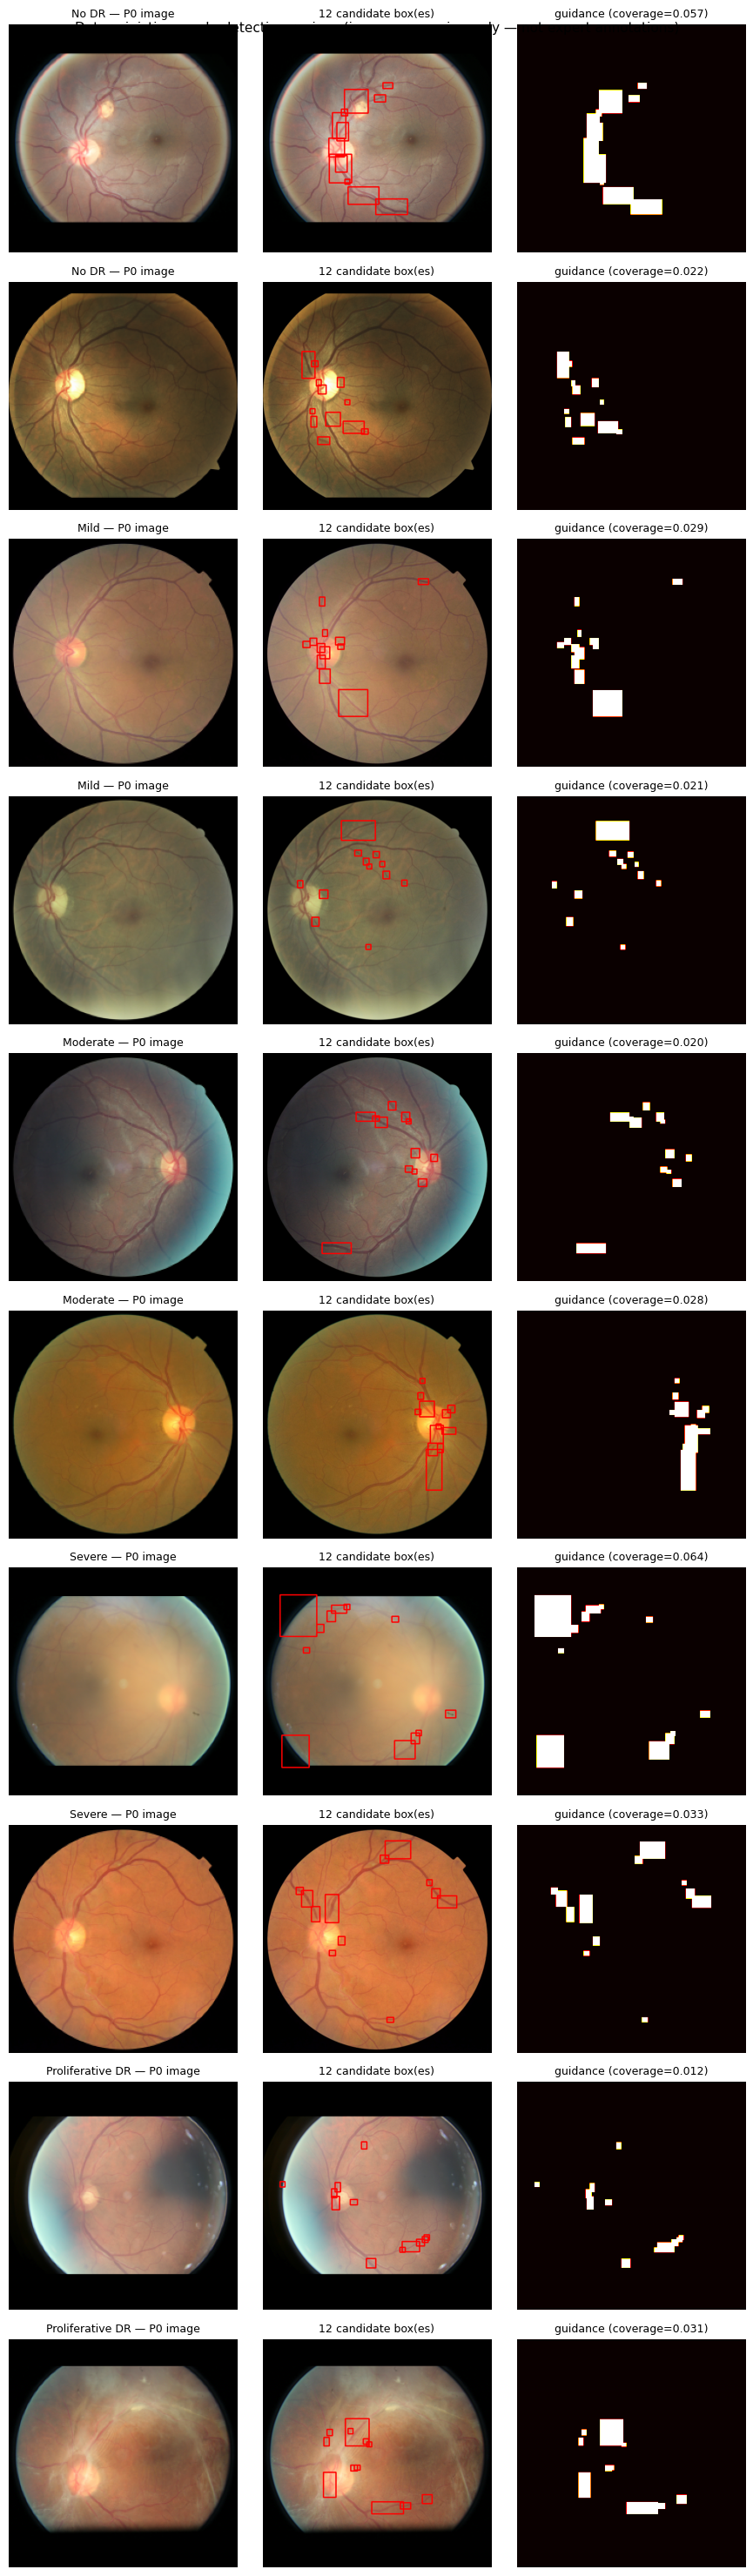

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M09_detection_guided_regions/detection_examples.png


In [9]:
examples_per_grade = 2
example_rows = []
for grade in range(NUM_CLASSES):
    grade_rows = train_df[train_df["level"] == grade].sample(
        n=min(examples_per_grade, (train_df["level"] == grade).sum()), random_state=SEED
    )
    example_rows.append(grade_rows)
example_df = pd.concat(example_rows, ignore_index=True)

fig, axes = plt.subplots(len(example_df), 3, figsize=(9, 3 * len(example_df)))

for row_idx, (_, row) in enumerate(example_df.iterrows()):
    image_full = preprocess_p0_full(row["filepath"])
    detection_resized = cv2.resize(image_full, (DETECTION_SIZE, DETECTION_SIZE), interpolation=cv2.INTER_AREA)
    guidance_map, boxes = generate_candidate_regions(image_full)

    display_image = cv2.resize(image_full, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)

    boxed_image = detection_resized.copy()
    for (x0, y0, x1, y1) in boxes:
        cv2.rectangle(boxed_image, (x0, y0), (x1, y1), (255, 0, 0), 2)

    axes[row_idx, 0].imshow(display_image)
    axes[row_idx, 0].set_title(f"{CLASS_NAMES[row['level']]} — P0 image", fontsize=9)

    axes[row_idx, 1].imshow(boxed_image)
    axes[row_idx, 1].set_title(f"{len(boxes)} candidate box(es)", fontsize=9)

    axes[row_idx, 2].imshow(guidance_map, cmap="hot", vmin=0, vmax=1)
    axes[row_idx, 2].set_title(f"guidance (coverage={guidance_map.mean():.3f})", fontsize=9)

    for col in range(3):
        axes[row_idx, col].axis("off")

fig.suptitle(
    "Deterministic pseudo-detection regions (image-processing only — not expert annotations)",
    fontsize=11,
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "detection_examples.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'detection_examples.png'}")

## 11. Dataset class and paired image+guidance augmentation

The RGB image and the guidance map must receive **exactly the same** horizontal flip,
rotation, translation and scale — otherwise the candidate boxes stop lining up with the
lesions they were detected from. `paired_train_transform()` samples one set of geometric
parameters using TorchVision's own `RandomAffine.get_params()` (the same sampling M07 used
internally, not a hand-rolled `random.uniform()` substitute) and applies it to both — bilinear
interpolation for the RGB image, **nearest-neighbour** for the guidance map, since the latter
is a binary region map, not a photograph. Colour jitter uses an actual `ColorJitter` module
instance (matching M07's parameter distribution and its internal random operation order,
rather than four separately-ordered manual adjustments) and applies to the RGB channels only;
the guidance channel is left in `[0, 1]` and untouched by colour jitter. The two are
concatenated into a single 4-channel tensor.

**Guidance-map caching.** The detector is deterministic and depends only on the fixed P0 crop
— it produces the exact same output every time for a given image, so recomputing it inside
`__getitem__` on every single epoch (potentially 600,000+ detector calls across a full
training run) is pure wasted CPU time. `build_guidance_cache()` runs the detector once per
image up front and writes each 224×224 guidance map to a small `.npy` file under `CACHE_DIR`;
the dataset then loads the cached array instead of recomputing it. The cache key includes the
detection parameters, so changing any of `DETECTION_SIZE` / `CLAHE_CLIP_LIMIT` /
`DARK_RESPONSE_PERCENTILE` / etc. in Section 3 naturally invalidates the old cache rather than
silently reusing stale guidance maps.

In [10]:
DETECTION_PARAM_KEY = (
    f"det{DETECTION_SIZE}_clahe{CLAHE_CLIP_LIMIT}_bg{BACKGROUND_SIGMA}_"
    f"pct{DARK_RESPONSE_PERCENTILE}_area{MIN_COMPONENT_AREA}-{MAX_COMPONENT_AREA}_"
    f"ar{MAX_ASPECT_RATIO}_boxes{MAX_CANDIDATE_BOXES}_pad{BOX_PADDING}"
)
GUIDANCE_CACHE_DIR = CACHE_DIR / DETECTION_PARAM_KEY
GUIDANCE_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _cache_path_for(image_name: str) -> Path:
    return GUIDANCE_CACHE_DIR / f"{Path(image_name).stem}.npy"


def build_guidance_cache(dataframe: pd.DataFrame) -> None:
    """Compute and cache the guidance map for every image in dataframe that isn't
    already cached. Safe to re-run: already-cached images are skipped."""
    missing = [
        row for _, row in dataframe.iterrows()
        if not _cache_path_for(row["image"]).exists()
    ]
    if not missing:
        print(f"Guidance cache already complete for {len(dataframe):,} images.")
        return

    for row in tqdm(missing, desc=f"caching guidance maps ({GUIDANCE_CACHE_DIR.name})"):
        image_full = preprocess_p0_full(row["filepath"])
        guidance_map, _ = generate_candidate_regions(image_full)
        np.save(_cache_path_for(row["image"]), guidance_map.astype(np.float32))

    print(f"Cached {len(missing):,} new guidance maps -> {GUIDANCE_CACHE_DIR}")


build_guidance_cache(train_df)
build_guidance_cache(val_df)

caching guidance maps (det512_clahe2.0_bg12.0_pct97.0_area3-350_ar4.0_boxes12_pad4):   0%|          | 0/24586 …

Cached 24,586 new guidance maps -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/cache/maxvit_tiny/M09_guidance_maps/det512_clahe2.0_bg12.0_pct97.0_area3-350_ar4.0_boxes12_pad4


caching guidance maps (det512_clahe2.0_bg12.0_pct97.0_area3-350_ar4.0_boxes12_pad4):   0%|          | 0/5270 […

Cached 5,270 new guidance maps -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/cache/maxvit_tiny/M09_guidance_maps/det512_clahe2.0_bg12.0_pct97.0_area3-350_ar4.0_boxes12_pad4


In [11]:
colour_jitter = transforms.ColorJitter(
    brightness=BRIGHTNESS_JITTER,
    contrast=CONTRAST_JITTER,
    saturation=SATURATION_JITTER,
    hue=HUE_JITTER,
)


def paired_train_transform(rgb_image: Image.Image, guidance_image: Image.Image):
    # Match M07 RandomHorizontalFlip behaviour.
    if torch.rand(1).item() < HORIZONTAL_FLIP_PROBABILITY:
        rgb_image = TF.hflip(rgb_image)
        guidance_image = TF.hflip(guidance_image)

    # Match M07 RandomAffine parameter sampling exactly.
    angle, translate, scale, shear = transforms.RandomAffine.get_params(
        degrees=[-ROTATION_DEGREES, ROTATION_DEGREES],
        translate=[TRANSLATE_FRACTION, TRANSLATE_FRACTION],
        scale_ranges=[SCALE_MIN, SCALE_MAX],
        shears=None,
        img_size=[IMAGE_SIZE, IMAGE_SIZE],
    )

    rgb_image = TF.affine(
        rgb_image, angle=angle, translate=translate, scale=scale, shear=shear,
        interpolation=transforms.InterpolationMode.BILINEAR, fill=0,
    )
    guidance_image = TF.affine(
        guidance_image, angle=angle, translate=translate, scale=scale, shear=shear,
        interpolation=transforms.InterpolationMode.NEAREST, fill=0,
    )

    # Same ColorJitter distribution and random operation order as M07.
    rgb_image = colour_jitter(rgb_image)

    rgb_tensor = TF.normalize(TF.to_tensor(rgb_image), mean=list(VIT_MEAN), std=list(VIT_STD))
    guidance_tensor = TF.to_tensor(guidance_image).clamp(0, 1)

    return rgb_tensor, guidance_tensor


def paired_eval_transform(rgb_image: Image.Image, guidance_image: Image.Image):
    rgb_tensor = TF.normalize(TF.to_tensor(rgb_image), mean=list(VIT_MEAN), std=list(VIT_STD))
    guidance_tensor = TF.to_tensor(guidance_image).clamp(0, 1)
    return rgb_tensor, guidance_tensor


class DRDatasetDetectionGuided(Dataset):
    """Returns a 4-channel (RGB + guidance) tensor, label and index. The detector never
    sees the label: generate_candidate_regions(image) only, not generate_candidate_regions
    (image, label). Guidance maps are loaded from the pre-built cache (see above), not
    recomputed on every access."""

    def __init__(self, dataframe: pd.DataFrame, train_mode: bool = False):
        self.df = dataframe.reset_index(drop=True)
        self.train_mode = train_mode

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, index: int):
        row = self.df.iloc[index]

        image_full = preprocess_p0_full(row["filepath"])
        rgb_224 = cv2.resize(image_full, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)

        cache_path = _cache_path_for(row["image"])
        if cache_path.exists():
            guidance_map = np.load(cache_path)
        else:
            # Fallback for any image the cache-build pass missed (e.g. added after
            # build_guidance_cache() ran) - computed on the fly and cached for next time.
            guidance_map, _ = generate_candidate_regions(image_full)
            np.save(cache_path, guidance_map.astype(np.float32))

        rgb_image = Image.fromarray(rgb_224)
        guidance_image = Image.fromarray((guidance_map * 255).astype(np.uint8))

        if self.train_mode:
            rgb_tensor, guidance_tensor = paired_train_transform(rgb_image, guidance_image)
        else:
            rgb_tensor, guidance_tensor = paired_eval_transform(rgb_image, guidance_image)

        model_input = torch.cat([rgb_tensor, guidance_tensor], dim=0)
        assert model_input.shape == (INPUT_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)

        label = int(row["level"])
        return model_input, label, index


train_ds = DRDatasetDetectionGuided(train_df, train_mode=True)
val_ds = DRDatasetDetectionGuided(val_df, train_mode=False)

print(f"train_ds: {len(train_ds):,} | val_ds: {len(val_ds):,}")

train_ds: 24,586 | val_ds: 5,270


## 12. DataLoaders

Ordinary shuffling, no `WeightedRandomSampler` — identical to M07. Validation uses
`shuffle=False` and the deterministic eval transform (no augmentation, so RGB/guidance
alignment is trivially exact there).

In [12]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 769 | Val batches: 165


## 13. Class weights and ordinal-aware loss

Exactly M07's loss, unmodified: clipped class-weighted cross-entropy plus a normalised
expected squared grade-distance penalty (weight 0.5).

In [13]:
class OrdinalPenalisedLoss(nn.Module):
    """Clipped weighted CE plus normalised expected squared grade distance (unchanged from M07)."""

    def __init__(
        self,
        num_classes: int = NUM_CLASSES,
        ordinal_weight: float = ORDINAL_PENALTY_WEIGHT,
        class_weights: torch.Tensor = None,
        label_smoothing: float = 0.0,
    ):
        super().__init__()
        self.ordinal_weight = ordinal_weight
        self.num_classes = num_classes
        self.max_squared_distance = float((num_classes - 1) ** 2)

        self.cross_entropy = nn.CrossEntropyLoss(
            weight=class_weights, label_smoothing=label_smoothing,
        )
        self.register_buffer("grade_values", torch.arange(num_classes, dtype=torch.float32))

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = self.cross_entropy(logits, targets)

        probabilities = F.softmax(logits, dim=1)
        target_grades = targets.to(dtype=probabilities.dtype).unsqueeze(1)
        squared_distances = (self.grade_values.unsqueeze(0) - target_grades).pow(2)
        normalised_distances = squared_distances / self.max_squared_distance
        ordinal_loss = (probabilities * normalised_distances).sum(dim=1).mean()

        return ce_loss + self.ordinal_weight * ordinal_loss


raw_weights = compute_class_weight(
    class_weight=CLASS_WEIGHT_METHOD,
    classes=np.arange(NUM_CLASSES),
    y=train_df["level"].to_numpy(),
)
clipped_weights = np.clip(raw_weights, CLASS_WEIGHT_CLIP_MIN, CLASS_WEIGHT_CLIP_MAX)
class_weights = torch.tensor(clipped_weights, dtype=torch.float32, device=device)

criterion = OrdinalPenalisedLoss(
    num_classes=NUM_CLASSES,
    ordinal_weight=ORDINAL_PENALTY_WEIGHT,
    class_weights=class_weights,
    label_smoothing=LABEL_SMOOTHING,
).to(device)
LOSS_FUNCTION_LABEL = "clipped_weighted_ce_plus_normalised_expected_squared_ordinal_penalty"

print("Loss: clipped weighted CE + 0.5 x normalised ordinal penalty (unchanged from M07)")
print("Raw balanced weights:", np.round(raw_weights, 3))
print("Clipped weights:", np.round(clipped_weights, 3))

Loss: clipped weighted CE + 0.5 x normalised ordinal penalty (unchanged from M07)
Raw balanced weights: [0.272 2.877 1.33  8.061 9.699]
Clipped weights: [0.5  2.5  1.33 2.5  2.5 ]


## 14. Four-channel MaxViT model

`timm` adapts the pretrained first-convolution weights to accept four channels. The exact
adaptation is determined by the installed `timm` implementation. The fourth channel has not
been pretrained on retinal lesion guidance, so its usefulness must be learned during M09
fine-tuning. **M09 begins from the pretrained ImageNet MaxViT model — it does not load M07's
trained checkpoint.**

The dummy forward test below deliberately runs in `eval()` mode. MaxViT's MBConv blocks
contain real BatchNorm layers (Sections 8/16 of the earlier notebooks discuss this same
point), and this shape test uses two all-zero images — passing that through the model in
`train()` mode would update BatchNorm's running statistics with a degenerate, uninformative
input before any real training has happened, contaminating the controlled comparison with
M07 (which never ran this dummy pass at all). The model's original mode is restored
immediately afterward.

In [14]:
def build_model(pretrained: bool = True) -> nn.Module:
    return timm.create_model(
        MODEL_NAME,
        pretrained=pretrained,
        num_classes=NUM_CLASSES,
        in_chans=INPUT_CHANNELS,
    ).to(device)


model = build_model(pretrained=True)
total_parameters = sum(p.numel() for p in model.parameters())

print(f"Model: {MODEL_NAME}  (in_chans={INPUT_CHANNELS})")
print(f"Total parameters: {total_parameters:,}")

first_conv = next(
    module for module in model.modules() if isinstance(module, nn.Conv2d)
)
print("First convolution input channels:", first_conv.in_channels)
assert first_conv.in_channels == INPUT_CHANNELS

dummy = torch.zeros(
    2,
    INPUT_CHANNELS,
    IMAGE_SIZE,
    IMAGE_SIZE,
    device=device,
)

# Use evaluation mode so the shape test does not alter any running
# normalisation statistics in the actual model that will be trained.
previous_training_mode = model.training
model.eval()

try:
    with torch.no_grad():
        output = model(dummy)
finally:
    model.train(previous_training_mode)

assert output.shape == (2, NUM_CLASSES)
print("Four-channel MaxViT forward test: PASSED")

Model: maxvit_tiny_tf_224.in1k  (in_chans=4)
Total parameters: 30,406,669
First convolution input channels: 4
Four-channel MaxViT forward test: PASSED


## 15. Optimiser and scheduler

Exactly M07's single-stage recipe: `AdamW`, 3-epoch linear warm-up, cosine decay after.

In [15]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

warmup_scheduler = LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS,
)
cosine_scheduler = CosineAnnealingLR(
    optimizer, T_max=max(1, MAX_EPOCHS - WARMUP_EPOCHS),
)
scheduler = SequentialLR(
    optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS],
)

SCHEDULER_CONFIG = {
    "name": "SequentialLR",
    "warmup_scheduler": "LinearLR",
    "warmup_start_factor": 0.1,
    "warmup_end_factor": 1.0,
    "warmup_epochs": WARMUP_EPOCHS,
    "main_scheduler": "CosineAnnealingLR",
}

print(f"Optimizer: AdamW(lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: {WARMUP_EPOCHS}-epoch linear warm-up -> CosineAnnealingLR")

Optimizer: AdamW(lr=5e-05, weight_decay=0.05)
Scheduler: 3-epoch linear warm-up -> CosineAnnealingLR


## 16. M07 → M09 controlled-ablation audit

Runs **before any training happens**, immediately after the optimiser/scheduler are built —
not at the end of the notebook, where a failure would only be discovered after a full training
run had already completed. Checks M09's own configuration against M07's **saved**
`config.json` (never M07's checkpoint) to confirm every control the ablation depends on
genuinely matches, that the required M07 result files actually exist, and that only the
intended, allowed differences exist between the two notebooks.

In [16]:
required_m07_files = [
    M07_LOG_DIR / "config.json",
    M07_LOG_DIR / "best_metrics.json",
    M07_LOG_DIR / "validation_metrics.json",
]

for required_file in required_m07_files:
    if not required_file.exists():
        raise FileNotFoundError(f"Required M07 file not found: {required_file}")

with open(M07_LOG_DIR / "config.json") as f:
    m07_config = json.load(f)

controlled_checks = [
    ("model_name", m07_config["model_name"], MODEL_NAME),
    ("seed", m07_config["seed"], SEED),
    ("image_size", m07_config["image_size"], IMAGE_SIZE),
    ("num_classes", m07_config["num_classes"], NUM_CLASSES),
    ("batch_size", m07_config["batch_size"], BATCH_SIZE),
    ("learning_rate", m07_config["learning_rate"], LEARNING_RATE),
    ("weight_decay", m07_config["weight_decay"], WEIGHT_DECAY),
    ("warmup_epochs", m07_config["warmup_epochs"], WARMUP_EPOCHS),
    ("max_epochs", m07_config["max_epochs"], MAX_EPOCHS),
    (
        "early_stopping_patience",
        m07_config["early_stopping_patience"],
        EARLY_STOPPING_PATIENCE,
    ),
    ("label_smoothing", m07_config["label_smoothing"], LABEL_SMOOTHING),
    ("grad_clip", m07_config["grad_clip"], GRAD_CLIP),
    ("qwk_tolerance", m07_config["qwk_tolerance"], QWK_TOLERANCE),
    ("use_class_weights", m07_config["use_class_weights"], USE_CLASS_WEIGHTS),
    ("use_wrs", m07_config["use_wrs"], USE_WRS),
    ("sampler", m07_config["sampler"], "shuffle"),
    ("class_weight_method", m07_config["class_weight_method"], CLASS_WEIGHT_METHOD),
    ("class_weight_clip_min", m07_config["class_weight_clip_min"], CLASS_WEIGHT_CLIP_MIN),
    ("class_weight_clip_max", m07_config["class_weight_clip_max"], CLASS_WEIGHT_CLIP_MAX),
    ("loss_function", m07_config["loss_function"], LOSS_FUNCTION_LABEL),
    (
        "ordinal_penalty_weight",
        m07_config["ordinal_penalty_weight"],
        ORDINAL_PENALTY_WEIGHT,
    ),
    ("optimizer", m07_config["optimizer"], "AdamW"),
    ("scheduler", m07_config["scheduler"], SCHEDULER_CONFIG),
    ("selection_metric", m07_config["selection_metric"], "validation_qwk"),
    (
        "selection_tiebreak",
        m07_config["selection_tiebreak"],
        "validation_macro_f1",
    ),
    ("training_mode", m07_config["training_mode"], TRAINING_MODE),
    ("preprocessing", m07_config["preprocessing"], "P0"),
    ("normalisation_mean", m07_config["normalisation_mean"], list(VIT_MEAN)),
    ("normalisation_std", m07_config["normalisation_std"], list(VIT_STD)),
    (
        "training_augmentation.horizontal_flip_probability",
        m07_config["training_augmentation"]["horizontal_flip_probability"],
        HORIZONTAL_FLIP_PROBABILITY,
    ),
    (
        "training_augmentation.rotation_degrees",
        m07_config["training_augmentation"]["rotation_degrees"],
        ROTATION_DEGREES,
    ),
    (
        "training_augmentation.brightness_jitter",
        m07_config["training_augmentation"]["brightness_jitter"],
        BRIGHTNESS_JITTER,
    ),
    (
        "training_augmentation.contrast_jitter",
        m07_config["training_augmentation"]["contrast_jitter"],
        CONTRAST_JITTER,
    ),
    (
        "training_augmentation.saturation_jitter",
        m07_config["training_augmentation"]["saturation_jitter"],
        SATURATION_JITTER,
    ),
    (
        "training_augmentation.hue_jitter",
        m07_config["training_augmentation"]["hue_jitter"],
        HUE_JITTER,
    ),
    (
        "translation_fraction",
        m07_config["training_augmentation"]["translation_fraction"],
        TRANSLATE_FRACTION,
    ),
    (
        "scale_min",
        m07_config["training_augmentation"]["scale_min"],
        SCALE_MIN,
    ),
    (
        "scale_max",
        m07_config["training_augmentation"]["scale_max"],
        SCALE_MAX,
    ),
    ("train_csv", m07_config["train_csv"], str(TRAIN_CSV)),
    ("val_csv", m07_config["val_csv"], str(VAL_CSV)),
]

audit_failures = []
for check_name, m07_value, m09_value in controlled_checks:
    if m07_value != m09_value:
        audit_failures.append((check_name, m07_value, m09_value))

if audit_failures:
    print("AUDIT FAILURES:")
    for check_name, m07_value, m09_value in audit_failures:
        print(f"  {check_name}: M07={m07_value!r}  M09={m09_value!r}")
    raise RuntimeError(
        f"{len(audit_failures)} controlled setting(s) differ between M07 and M09 - "
        "this is no longer a clean single-variable ablation."
    )

allowed_differences = [
    "experiment_id", "run_name", "experiment_type", "predecessor_experiment",
    "input_channels", "detection_pipeline", "total_parameters",
]
print(f"Required M07 result files found: {len(required_m07_files)}/{len(required_m07_files)}")
print("Controlled settings verified identical to M07:")
for check_name, _, _ in controlled_checks:
    print(f"  - {check_name}")
print()
print("Allowed (intended) differences:", ", ".join(allowed_differences))
print()
print("M07 -> M09 controlled-ablation audit: PASSED")

Required M07 result files found: 3/3
Controlled settings verified identical to M07:
  - model_name
  - seed
  - image_size
  - num_classes
  - batch_size
  - learning_rate
  - weight_decay
  - warmup_epochs
  - max_epochs
  - early_stopping_patience
  - label_smoothing
  - grad_clip
  - qwk_tolerance
  - use_class_weights
  - use_wrs
  - sampler
  - class_weight_method
  - class_weight_clip_min
  - class_weight_clip_max
  - loss_function
  - ordinal_penalty_weight
  - optimizer
  - scheduler
  - selection_metric
  - selection_tiebreak
  - training_mode
  - preprocessing
  - normalisation_mean
  - normalisation_std
  - training_augmentation.horizontal_flip_probability
  - training_augmentation.rotation_degrees
  - training_augmentation.brightness_jitter
  - training_augmentation.contrast_jitter
  - training_augmentation.saturation_jitter
  - training_augmentation.hue_jitter
  - translation_fraction
  - scale_min
  - scale_max
  - train_csv
  - val_csv

Allowed (intended) differences: ex

## 17. Training and validation functions

Same structure as M07's `run_epoch()`, with two additions M07 did not have: raw logits are
collected alongside probabilities (needed later for temperature scaling in a possible M13),
and non-finite logits/loss are checked explicitly **before backpropagation** rather than only
being caught implicitly downstream.

In [17]:
use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)


def run_epoch(
    model: nn.Module,
    loader,
    optimizer=None,
    train_mode: bool = True,
    grad_clip: float = GRAD_CLIP,
):
    if train_mode and optimizer is None:
        raise ValueError("An optimizer must be supplied during training.")

    model.train() if train_mode else model.eval()

    total_loss = 0.0
    total_samples = 0
    all_labels, all_preds, all_probs, all_logits, all_indices = [], [], [], [], []

    description = "train" if train_mode else "eval"

    for images, labels, indices in tqdm(loader, leave=False, desc=description):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train_mode):
            with torch.autocast(device_type=device.type, enabled=use_amp):
                logits = model(images)

                if not torch.isfinite(logits).all():
                    raise RuntimeError("Non-finite logits detected.")

                loss = criterion(logits, labels)

                if not torch.isfinite(loss):
                    raise RuntimeError("Non-finite loss detected.")

        if train_mode:
            scaler.scale(loss).backward()
            if grad_clip > 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()

        probabilities = F.softmax(logits.detach(), dim=1)
        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_preds.extend(probabilities.argmax(dim=1).cpu().tolist())
        all_labels.extend(labels.detach().cpu().tolist())
        all_probs.extend(probabilities.cpu().tolist())
        all_logits.extend(logits.detach().cpu().tolist())
        all_indices.extend(indices.cpu().tolist())

    if total_samples == 0:
        raise RuntimeError("The DataLoader produced no samples.")

    epoch_qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    if not np.isfinite(epoch_qwk):
        raise RuntimeError("QWK became NaN or infinity during the epoch.")

    return {
        "loss": total_loss / total_samples,
        "accuracy": accuracy_score(all_labels, all_preds),
        "balanced_accuracy": balanced_accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "qwk": epoch_qwk,
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
        "logits": all_logits,
        "indices": all_indices,
    }


def checkpoint_improved(
    val_qwk: float, val_macro_f1: float, best_qwk: float, best_macro_f1: float,
    tolerance: float = QWK_TOLERANCE,
) -> bool:
    """Validation QWK primary, validation macro-F1 tie-break."""
    if val_qwk > best_qwk + tolerance:
        return True
    if abs(val_qwk - best_qwk) <= tolerance and val_macro_f1 > best_macro_f1:
        return True
    return False

## 18. Early-stopping training loop

Identical structure and checkpoint rule to M07. `training_history.csv` is re-saved after
every epoch.

In [18]:
history = []
best_qwk = -1.0
best_macro_f1 = -1.0
patience_left = EARLY_STOPPING_PATIENCE

print("=" * 60)
print(f"  {RUN_NAME}")
print("=" * 60)
print(f"{'Epoch':<8} {'Tr Loss':>10} {'Tr QWK':>8} {'Val Loss':>10} {'Val QWK':>8} {'Val F1':>8}")
print("-" * 60)

for epoch in range(1, MAX_EPOCHS + 1):
    lr_used = optimizer.param_groups[0]["lr"]

    train_metrics = run_epoch(model, train_loader, optimizer=optimizer, train_mode=True)
    val_metrics = run_epoch(model, val_loader, train_mode=False)
    scheduler.step()

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_qwk": train_metrics["qwk"],
        "val_qwk": val_metrics["qwk"],
        "learning_rate": lr_used,
    }
    history.append(epoch_record)
    pd.DataFrame(history).to_csv(RUN_LOG_DIR / "training_history.csv", index=False)

    marker = ""
    if checkpoint_improved(val_metrics["qwk"], val_metrics["macro_f1"], best_qwk, best_macro_f1):
        best_qwk = val_metrics["qwk"]
        best_macro_f1 = val_metrics["macro_f1"]
        patience_left = EARLY_STOPPING_PATIENCE
        torch.save(
            {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_qwk": val_metrics["qwk"],
            },
            BEST_CHECKPOINT_PATH,
        )
        marker = "  [best]"
    else:
        patience_left -= 1

    print(
        f"{epoch:<8} {train_metrics['loss']:>10.4f} {train_metrics['qwk']:>8.4f} "
        f"{val_metrics['loss']:>10.4f} {val_metrics['qwk']:>8.4f} {val_metrics['macro_f1']:>8.4f}"
        f"{marker}"
    )

    if patience_left <= 0:
        print(f"Early stopping at epoch {epoch}.")
        break

print(f"\nBest val QWK = {best_qwk:.4f} (macro-F1 = {best_macro_f1:.4f}) -> {BEST_CHECKPOINT_PATH.name}")

  M09_detection_guided_regions
Epoch       Tr Loss   Tr QWK   Val Loss  Val QWK   Val F1
------------------------------------------------------------


train:   0%|          | 0/769 [00:00<?, ?it/s]

eval:   0%|          | 0/165 [00:00<?, ?it/s]

1            1.3859   0.1746     1.2156   0.4228   0.2549  [best]


train:   0%|          | 0/769 [00:00<?, ?it/s]

...

eval:   0%|          | 0/165 [00:00<?, ?it/s]

12           0.2649   0.9042     1.7432   0.7001   0.5085


train:   0%|          | 0/769 [00:00<?, ?it/s]

eval:   0%|          | 0/165 [00:00<?, ?it/s]

13           0.2158   0.9257     1.7652   0.6829   0.5233
Early stopping at epoch 13.

Best val QWK = 0.7485 (macro-F1 = 0.5558) -> best.pt


## 19. Training curves

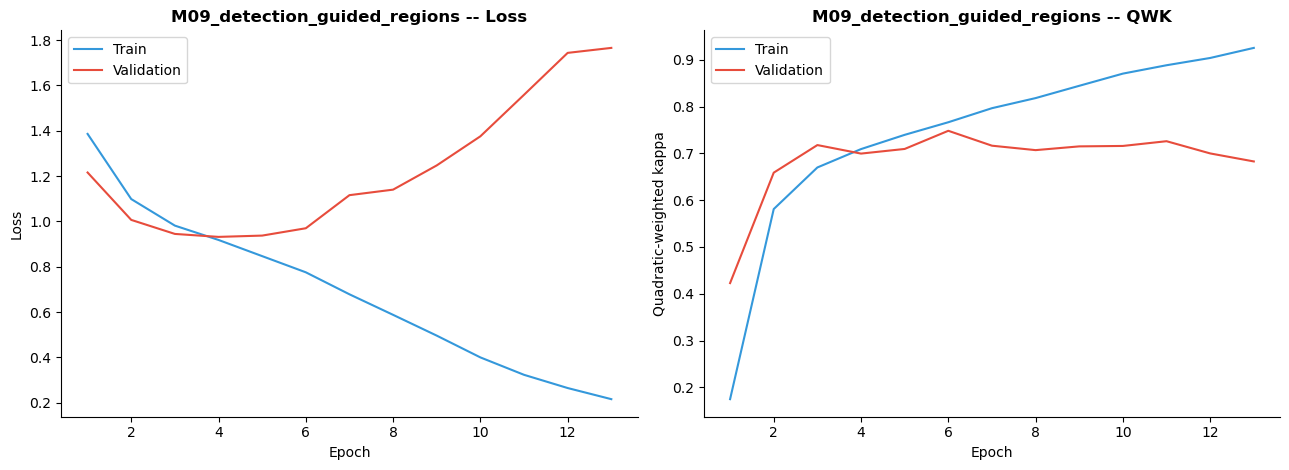

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M09_detection_guided_regions/training_curves.png


In [19]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train", color="#3498DB")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation", color="#E74C3C")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title(f"{RUN_NAME} -- Loss", fontweight="bold")
axes[0].legend(); axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(history_df["epoch"], history_df["train_qwk"], label="Train", color="#3498DB")
axes[1].plot(history_df["epoch"], history_df["val_qwk"], label="Validation", color="#E74C3C")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Quadratic-weighted kappa")
axes[1].set_title(f"{RUN_NAME} -- QWK", fontweight="bold")
axes[1].legend(); axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "training_curves.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'training_curves.png'}")

## 20. Validation metrics and confusion matrix

Best checkpoint reloaded fresh and re-evaluated on `val_loader` — not the internal test set.

In [20]:
best_checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=device, weights_only=False)

eval_model = build_model(pretrained=False)
eval_model.load_state_dict(best_checkpoint["model_state"])

print(f"Loaded: {BEST_CHECKPOINT_PATH.name}")
print(f"epoch={best_checkpoint['epoch']}  val_qwk={best_checkpoint['val_qwk']:.4f}  "
      f"val_macro_f1={best_checkpoint['val_macro_f1']:.4f}")

final_val_metrics = run_epoch(eval_model, val_loader, train_mode=False)

val_macro_precision = precision_score(
    final_val_metrics["labels"], final_val_metrics["preds"], average="macro", zero_division=0,
)
val_macro_recall = recall_score(
    final_val_metrics["labels"], final_val_metrics["preds"], average="macro", zero_division=0,
)

print()
print("=" * 60)
print(f"  {RUN_NAME} -- VALIDATION RESULTS (best checkpoint)")
print("=" * 60)
print(f"  Val QWK               : {final_val_metrics['qwk']:.4f}")
print(f"  Val accuracy           : {final_val_metrics['accuracy']:.4f}")
print(f"  Val balanced accuracy  : {final_val_metrics['balanced_accuracy']:.4f}")
print(f"  Val macro F1           : {final_val_metrics['macro_f1']:.4f}")
print(f"  Val macro precision    : {val_macro_precision:.4f}")
print(f"  Val macro recall       : {val_macro_recall:.4f}")
print()
print(classification_report(
    final_val_metrics["labels"], final_val_metrics["preds"],
    labels=list(range(NUM_CLASSES)), target_names=CLASS_NAMES, digits=3, zero_division=0,
))

Loaded: best.pt
epoch=6  val_qwk=0.7485  val_macro_f1=0.5558


eval:   0%|          | 0/165 [00:00<?, ?it/s]


  M09_detection_guided_regions -- VALIDATION RESULTS (best checkpoint)
  Val QWK               : 0.7485
  Val accuracy           : 0.8127
  Val balanced accuracy  : 0.5315
  Val macro F1           : 0.5558
  Val macro precision    : 0.5929
  Val macro recall       : 0.5315

                  precision    recall  f1-score   support

           No DR      0.866     0.952     0.907      3873
            Mild      0.197     0.109     0.140       368
        Moderate      0.729     0.544     0.623       800
          Severe      0.492     0.465     0.478       127
Proliferative DR      0.682     0.588     0.632       102

        accuracy                          0.813      5270
       macro avg      0.593     0.532     0.556      5270
    weighted avg      0.786     0.813     0.795      5270



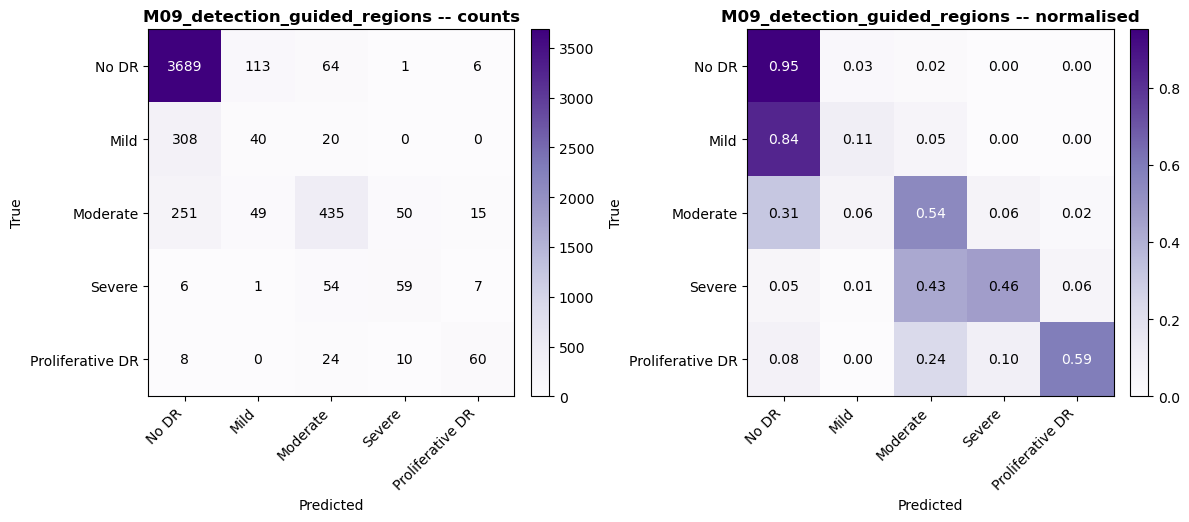

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M09_detection_guided_regions/confusion_matrix.png


In [21]:
per_class_precision = precision_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)
per_class_recall = recall_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)
per_class_f1 = f1_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)

cm_counts = confusion_matrix(final_val_metrics["labels"], final_val_metrics["preds"])
cm_normalised = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, data, fmt, title in [
    (axes[0], cm_counts, "d", f"{RUN_NAME} -- counts"),
    (axes[1], cm_normalised, ".2f", f"{RUN_NAME} -- normalised"),
]:
    im = ax.imshow(data, interpolation="nearest", cmap="Purples")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontweight="bold")
    thresh = data.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(data[i, j], fmt), ha="center", va="center",
                     color="white" if data[i, j] > thresh else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "confusion_matrix.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'confusion_matrix.png'}")

### Mild-DR and ordinal error diagnostics

Same combined diagnostic block used in M05-M08: Mild precision/recall/F1, Mild confusion
counts, and the full grade-error profile, so M09's fine-grained behaviour is directly
comparable to every prior notebook.

In [22]:
labels_array = np.asarray(final_val_metrics["labels"])
preds_array = np.asarray(final_val_metrics["preds"])

grade_error_array = preds_array - labels_array
absolute_grade_error = np.abs(grade_error_array)

mild_mask = labels_array == 1
moderate_mask = labels_array == 2

mild_precision = float(per_class_precision[1])
mild_recall = float(per_class_recall[1])
mild_f1 = float(per_class_f1[1])
moderate_f1 = float(per_class_f1[2])

mild_correct = int(np.sum(mild_mask & (preds_array == 1)))
mild_to_no_dr = int(np.sum(mild_mask & (preds_array == 0)))
mild_to_moderate = int(np.sum(mild_mask & (preds_array == 2)))

mean_absolute_grade_error = float(absolute_grade_error.mean())
within_one_grade_accuracy = float((absolute_grade_error <= 1).mean())
adjacent_grade_error_rate = float((absolute_grade_error == 1).mean())
large_grade_error_rate = float((absolute_grade_error > 1).mean())

zero_to_four = int(np.sum((labels_array == 0) & (preds_array == 4)))
four_to_zero = int(np.sum((labels_array == 4) & (preds_array == 0)))

ordinal_error_distribution = {
    str(distance): int(np.sum(absolute_grade_error == distance))
    for distance in range(NUM_CLASSES)
}

print(f"Mild precision           : {mild_precision:.4f}")
print(f"Mild recall              : {mild_recall:.4f}")
print(f"Mild F1                  : {mild_f1:.4f}")
print(f"Mild correctly predicted : {mild_correct}")
print(f"Mild -> No DR errors     : {mild_to_no_dr}")
print(f"Mild -> Moderate errors  : {mild_to_moderate}")
print(f"Moderate F1              : {moderate_f1:.4f}")
print(f"Mean absolute grade error: {mean_absolute_grade_error:.4f}")
print(f"Within-one-grade accuracy: {within_one_grade_accuracy:.4f}")
print(f"Adjacent error rate      : {adjacent_grade_error_rate:.4f}")
print(f"Large grade-error rate   : {large_grade_error_rate:.4f}")
print(f"No DR -> PDR errors      : {zero_to_four}")
print(f"PDR -> No DR errors      : {four_to_zero}")

Mild precision           : 0.1970
Mild recall              : 0.1087
Mild F1                  : 0.1401
Mild correctly predicted : 40
Mild -> No DR errors     : 308
Mild -> Moderate errors  : 20
Moderate F1              : 0.6228
Mean absolute grade error: 0.2653
Within-one-grade accuracy: 0.9287
Adjacent error rate      : 0.1159
Large grade-error rate   : 0.0713
No DR -> PDR errors      : 6
PDR -> No DR errors      : 8


## 21. Direct comparison with M07

Loads M07's **saved JSON results**, not its checkpoint. The direct ablation is M07 seed 42
vs M09 seed 42 — M08 (a seed replicate of M07) is not the comparison target.

                   Metric        M07        M09  Difference
                      QWK   0.761905   0.748463   -0.013442
                 Macro-F1   0.551890   0.555825    0.003935
        Balanced accuracy   0.550665   0.531548   -0.019117
           Mild precision   0.159483   0.197044    0.037562
              Mild recall   0.100543   0.108696    0.008152
                  Mild F1   0.123333   0.140105    0.016772
              Moderate F1   0.575603   0.622763    0.047160
            Mild -> No DR 306.000000 308.000000    2.000000
         Mild -> Moderate  25.000000  20.000000   -5.000000
Mean absolute grade error   0.270588   0.265275   -0.005313
   Large-grade error rate   0.069639   0.071347    0.001708


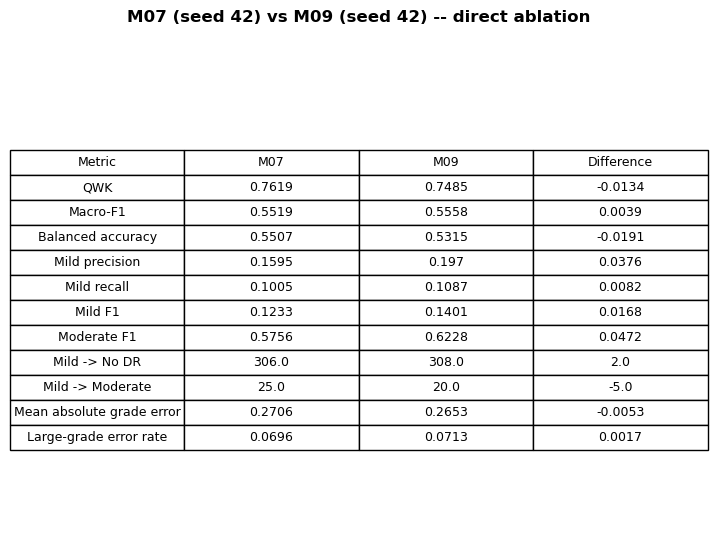

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M09_detection_guided_regions/m07_m09_comparison.png


In [23]:
with open(M07_LOG_DIR / "best_metrics.json") as f:
    m07_best_metrics = json.load(f)
with open(M07_LOG_DIR / "validation_metrics.json") as f:
    m07_validation_metrics = json.load(f)

# M07's validation_metrics.json has no top-level "moderate_f1" key - Moderate F1 is
# stored inside the per-class list at index 2 (Moderate is grade 2).
m07_moderate_f1 = float(m07_validation_metrics["per_class_f1"][2])

comparison_rows = [
    ("QWK", m07_best_metrics["val_qwk"], final_val_metrics["qwk"]),
    ("Macro-F1", m07_best_metrics["val_macro_f1"], final_val_metrics["macro_f1"]),
    ("Balanced accuracy", m07_best_metrics["val_balanced_accuracy"], final_val_metrics["balanced_accuracy"]),
    ("Mild precision", m07_validation_metrics["mild_precision"], mild_precision),
    ("Mild recall", m07_validation_metrics["mild_recall"], mild_recall),
    ("Mild F1", m07_validation_metrics["mild_f1"], mild_f1),
    ("Moderate F1", m07_moderate_f1, moderate_f1),
    ("Mild -> No DR", m07_validation_metrics["mild_to_no_dr"], mild_to_no_dr),
    ("Mild -> Moderate", m07_validation_metrics["mild_to_moderate"], mild_to_moderate),
    ("Mean absolute grade error", m07_validation_metrics["mean_absolute_grade_error"], mean_absolute_grade_error),
    ("Large-grade error rate", m07_validation_metrics["large_grade_error_rate"], large_grade_error_rate),
]

comparison_df = pd.DataFrame(comparison_rows, columns=["Metric", "M07", "M09"])
comparison_df["Difference"] = comparison_df["M09"] - comparison_df["M07"]

print(comparison_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 0.5 * len(comparison_df) + 1))
ax.axis("off")
table = ax.table(
    cellText=comparison_df.round(4).astype(str).values,
    colLabels=comparison_df.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
ax.set_title("M07 (seed 42) vs M09 (seed 42) -- direct ablation", fontweight="bold", pad=20)

plt.savefig(FIGURE_DIR / "m07_m09_comparison.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'm07_m09_comparison.png'}")

comparison_df.to_csv(RUN_LOG_DIR / "m07_m09_comparison.csv", index=False)

## 22. Save logs and validation predictions

`detection_summary.csv` records the detection pipeline's behaviour across the full
validation set (box counts, coverage) — used both for the audit and for the extended
prediction CSV below. The prediction CSV includes raw logits (for a possible future M13
temperature-scaling notebook), per-image detection statistics, and everything logged in
M05-M08.

In [24]:
detection_rows = []
for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc="detection summary (validation)"):
    image_full = preprocess_p0_full(row["filepath"])
    guidance_map, boxes = generate_candidate_regions(image_full)
    detection_rows.append({
        "image": row["image"],
        "num_candidate_boxes": len(boxes),
        "guidance_coverage": float(guidance_map.mean()),
    })
detection_summary_df = pd.DataFrame(detection_rows)
detection_summary_df.to_csv(RUN_LOG_DIR / "detection_summary.csv", index=False)
print(f"Saved -> {RUN_LOG_DIR / 'detection_summary.csv'}")

detection summary (validation):   0%|          | 0/5270 [00:00<?, ?it/s]

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M09_detection_guided_regions/detection_summary.csv


In [25]:
experiment_config = {
    "experiment_id": EXPERIMENT_ID,
    "run_name": RUN_NAME,
    "experiment_type": EXPERIMENT_TYPE,
    "predecessor_experiment": PREDECESSOR_EXPERIMENT,
    "experimental_change": "add_coarse_candidate_region_guidance_channel",
    "model_name": MODEL_NAME,
    "pretrained": True,
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "input_channels": INPUT_CHANNELS,
    "rgb_channels": RGB_CHANNELS,
    "guidance_channels": GUIDANCE_CHANNELS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "optimizer": "AdamW",
    "warmup_epochs": WARMUP_EPOCHS,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "use_class_weights": USE_CLASS_WEIGHTS,
    "use_wrs": USE_WRS,
    "sampler": "shuffle",
    "loss_function": LOSS_FUNCTION_LABEL,
    "label_smoothing": LABEL_SMOOTHING,
    "class_weight_method": CLASS_WEIGHT_METHOD,
    "class_weight_clip_min": CLASS_WEIGHT_CLIP_MIN,
    "class_weight_clip_max": CLASS_WEIGHT_CLIP_MAX,
    "raw_class_weights": raw_weights.tolist(),
    "clipped_class_weights": clipped_weights.tolist(),
    "ordinal_penalty_type": "normalised_expected_squared_grade_distance",
    "ordinal_penalty_weight": ORDINAL_PENALTY_WEIGHT,
    "grad_clip": GRAD_CLIP,
    "qwk_tolerance": QWK_TOLERANCE,
    "selection_metric": "validation_qwk",
    "selection_tiebreak": "validation_macro_f1",
    "training_mode": TRAINING_MODE,
    "preprocessing": "P0",
    "scheduler": SCHEDULER_CONFIG,
    "normalisation_mean": list(VIT_MEAN),
    "normalisation_std": list(VIT_STD),
    "training_augmentation": {
        "policy": "safe_retinal_augmentation",
        "geometric_transform": "single_random_affine_paired_with_guidance",
        "interpolation_rgb": "bilinear",
        "interpolation_guidance": "nearest",
        "horizontal_flip_probability": HORIZONTAL_FLIP_PROBABILITY,
        "rotation_degrees": ROTATION_DEGREES,
        "brightness_jitter": BRIGHTNESS_JITTER,
        "contrast_jitter": CONTRAST_JITTER,
        "saturation_jitter": SATURATION_JITTER,
        "hue_jitter": HUE_JITTER,
        "translation_fraction": TRANSLATE_FRACTION,
        "scale_min": SCALE_MIN,
        "scale_max": SCALE_MAX,
        "vertical_flip": False,
        "mixup": False,
        "random_erasing": False,
    },
    "detection_pipeline": {
        "method": "deterministic_classical_image_processing",
        "guidance_type": "deterministic_pseudo_detection_bounding_regions",
        "expert_annotations_used": False,
        "validation_labels_used_to_tune_detector": False,
        "detection_size": DETECTION_SIZE,
        "clahe_clip_limit": CLAHE_CLIP_LIMIT,
        "clahe_tile_grid_size": list(CLAHE_TILE_GRID_SIZE),
        "background_sigma": BACKGROUND_SIGMA,
        "dark_response_percentile": DARK_RESPONSE_PERCENTILE,
        "min_component_area": MIN_COMPONENT_AREA,
        "max_component_area": MAX_COMPONENT_AREA,
        "max_aspect_ratio": MAX_ASPECT_RATIO,
        "max_candidate_boxes": MAX_CANDIDATE_BOXES,
        "box_padding": BOX_PADDING,
        "guidance_map_type": GUIDANCE_MAP_TYPE,
    },
    "total_parameters": total_parameters,
    "train_size": len(train_df),
    "val_size": len(val_df),
    "num_workers": NUM_WORKERS,
    "mixed_precision": use_amp,
    "device": torch.cuda.get_device_name(0),
    "torch_version": torch.__version__,
    "timm_version": timm.__version__,
    "train_csv": str(TRAIN_CSV),
    "val_csv": str(VAL_CSV),
}

with open(RUN_LOG_DIR / "config.json", "w") as f:
    json.dump(experiment_config, f, indent=2)
print(f"Saved -> {RUN_LOG_DIR / 'config.json'}")

best_metrics = {
    "epoch": best_checkpoint["epoch"],
    "val_loss": best_checkpoint["val_loss"],
    "val_accuracy": best_checkpoint["val_accuracy"],
    "val_balanced_accuracy": best_checkpoint["val_balanced_accuracy"],
    "val_macro_f1": best_checkpoint["val_macro_f1"],
    "val_qwk": best_checkpoint["val_qwk"],
}
with open(RUN_LOG_DIR / "best_metrics.json", "w") as f:
    json.dump(best_metrics, f, indent=2)
print(f"Saved -> {RUN_LOG_DIR / 'best_metrics.json'}")

validation_metrics = {
    "qwk": final_val_metrics["qwk"],
    "accuracy": final_val_metrics["accuracy"],
    "balanced_accuracy": final_val_metrics["balanced_accuracy"],
    "macro_f1": final_val_metrics["macro_f1"],
    "macro_precision": val_macro_precision,
    "macro_recall": val_macro_recall,
    "per_class_precision": per_class_precision.tolist(),
    "per_class_recall": per_class_recall.tolist(),
    "per_class_f1": per_class_f1.tolist(),
    "mild_precision": mild_precision,
    "mild_recall": mild_recall,
    "mild_f1": mild_f1,
    "moderate_f1": moderate_f1,
    "mild_correct": mild_correct,
    "mild_to_no_dr": mild_to_no_dr,
    "mild_to_moderate": mild_to_moderate,
    "mean_absolute_grade_error": mean_absolute_grade_error,
    "within_one_grade_accuracy": within_one_grade_accuracy,
    "adjacent_grade_error_rate": adjacent_grade_error_rate,
    "large_grade_error_rate": large_grade_error_rate,
    "zero_to_four": zero_to_four,
    "four_to_zero": four_to_zero,
    "ordinal_error_distribution": ordinal_error_distribution,
}
with open(RUN_LOG_DIR / "validation_metrics.json", "w") as f:
    json.dump(validation_metrics, f, indent=2)
print(f"Saved -> {RUN_LOG_DIR / 'validation_metrics.json'}")

pred_rows = val_df.iloc[final_val_metrics["indices"]].reset_index(drop=True).copy()
pred_rows["true_label"] = final_val_metrics["labels"]
pred_rows["predicted_label"] = final_val_metrics["preds"]

logits_array = np.array(final_val_metrics["logits"])
probs_array = np.array(final_val_metrics["probs"])
for grade in range(NUM_CLASSES):
    pred_rows[f"logit_grade_{grade}"] = logits_array[:, grade]
for grade in range(NUM_CLASSES):
    pred_rows[f"prob_grade_{grade}"] = probs_array[:, grade]

pred_rows["confidence"] = probs_array.max(axis=1)
pred_rows["correct"] = pred_rows["true_label"] == pred_rows["predicted_label"]
pred_rows["grade_error"] = pred_rows["predicted_label"] - pred_rows["true_label"]
pred_rows["absolute_grade_error"] = pred_rows["grade_error"].abs()

assert pred_rows["image"].is_unique, (
    "Validation prediction image identifiers are not unique."
)
assert detection_summary_df["image"].is_unique, (
    "Detection summary image identifiers are not unique."
)

pred_rows = pred_rows.merge(
    detection_summary_df,
    on="image",
    how="left",
    validate="one_to_one",
)

if pred_rows[["num_candidate_boxes", "guidance_coverage"]].isna().any().any():
    raise RuntimeError(
        "Some validation predictions are missing detection statistics."
    )

prediction_columns = [
    "image", "patient_id", "eye", "true_label", "predicted_label",
    "logit_grade_0", "logit_grade_1", "logit_grade_2", "logit_grade_3", "logit_grade_4",
    "prob_grade_0", "prob_grade_1", "prob_grade_2", "prob_grade_3", "prob_grade_4",
    "confidence", "correct", "grade_error", "absolute_grade_error",
    "num_candidate_boxes", "guidance_coverage",
]
pred_rows[prediction_columns].to_csv(RUN_LOG_DIR / "validation_predictions.csv", index=False)

print(f"Saved -> {RUN_LOG_DIR / 'validation_predictions.csv'}  ({len(pred_rows):,} rows)")
print()
print("training_history.csv was already saved incrementally during training.")

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M09_detection_guided_regions/config.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M09_detection_guided_regions/best_metrics.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M09_detection_guided_regions/validation_metrics.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M09_detection_guided_regions/validation_predictions.csv  (5,270 rows)

training_history.csv was already saved incrementally during training.


## 23. Experiment conclusion

*This section intentionally contains only the questions to be answered — replace it with the
actual conclusion after this notebook has been run. Do not leave the placeholder text below
in the final executed commit.*

To be answered after running:

- Did validation QWK improve or decline relative to M07 (Section 21)?
- Did Mild recall and/or Mild F1 improve?
- Did Mild → No-DR errors fall?
- Did false positives increase elsewhere (e.g. did specificity or another grade's precision
  drop) as a possible side effect of the added guidance channel?
- Did the guidance detector, on inspection of the validation predictions and the detection
  summary, often select regions that turned out to be irrelevant to the actual DR grade?
- Do the results justify continuing to a possible M10 (pixel-level pseudo-segmentation
  guidance), or does M09 already show the coarse-region approach isn't paying off?
- What are the limitations of pseudo-detection regions as used here — no ground truth to
  validate against, a fixed (not learned or tuned) threshold, and no guarantee the detector
  actually corresponds to clinically meaningful lesions rather than image-processing
  artefacts (vessel crossings, reflections, etc.)?

## 24. Before-run Git commit

Run from the project root **after** reviewing this unexecuted notebook, before training:

```bash
cd "/scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy"

git add notebooks/maxvit_tiny/M09_detection_guided_regions.ipynb
git diff --cached --name-only
```

This should show only `notebooks/maxvit_tiny/M09_detection_guided_regions.ipynb`. Then
confirm no checkpoint is staged:

```bash
git diff --cached --name-only | grep -E "\.pt$|\.pth$|checkpoints"
```

This must return nothing. Then:

```bash
git commit -m "Implement M09 detection-guided MaxViT ablation"
git push origin main
git status
```